# Accuracy Analysis: Prediction Market vs. Polls

**DS2500 — Programming with Data | Northeastern University**  
**Team:** Sebastian Brookes, Shiven Mishra

Which source more accurately predicted the actual outcomes of the 2024 U.S. presidential
election? This notebook compares **Polymarket** (prediction market odds) against
**FiveThirtyEight** (polling averages) on state-level winner calls, tracking how their
accuracy evolved over time and culminated on election night.

In [33]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import fisher_exact

# add project root to path so we can import from src/
PROJECT_ROOT = str(Path.cwd().parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.visualize.accuracy_plots import (
    load_data,
    latest_per_state,
    predict_winner_pm,
    predict_winner_538,
    compute_accuracy,
    compute_daily_accuracy,
    build_head_to_head_metrics,
    build_polymarket_trajectory_metrics,
    build_ev_comparison_metrics,
    plot_timeseries_crossover,
    plot_head_to_head,
    plot_polymarket_trajectory,
    plot_ev_comparison,
    configure_plot_style,
    OVERLAP_STATES,
    SWING_OVERLAP,
)

configure_plot_style()

# lower DPI for inline display
plt.rcParams["figure.dpi"] = 150


## Methodology

### Data sources

| Source | What it provides | Granularity |
| --- | --- | --- |
| **Polymarket** | Daily Trump win-probability per state | State and day |
| **FiveThirtyEight** | Polling averages (Trump % and Dem %) | State and day |
| **FEC** | Official 2024 election results | State-level |

### Overlap constraints

Polymarket's state-level markets launched on different dates, so a fair head-to-head
comparison is only possible for the **13 states** where both sources have daily data
through **September 12, 2024** (when the last Polymarket state market opened):
AZ, CA, FL, GA, MI, MN, NC, NH, NV, OH, PA, TX, WI.

Luckily, all seven **swing states** appear in this intersection: AZ, GA, MI, NC, NV, PA, WI.

### Winner-call methodology

Both Polymarket and FiveThirtyEight give us numbers, but we need a simple yes-or-no
answer for each state: **did the source predict Trump or Harris would win?** To get
that answer, we apply a straightforward rule to each source:

- **Polymarket** gives a probability that Trump wins each state (0 to 1). If that
  probability is above 0.5 (i.e., the market thinks Trump is more likely to win than
  lose), we count it as a Trump prediction. Otherwise, Harris.
- **FiveThirtyEight** gives vote-share percentages for each candidate. If Trump's
  percentage is higher than the Democratic candidate's percentage, we count it as a
  Trump prediction. Otherwise, Harris.

In both cases, we are asking: **which candidate does the source favor in this
state?** We then check whether that prediction matches the actual FEC-certified winner.
A prediction is "correct" if the favored candidate did win, and "incorrect" if they
didn't.

### How the pipeline works

The computation functions imported above (from `src/visualize/accuracy_plots.py`) solve
three data-wrangling problems:

1. **Filling in missing dates for FiveThirtyEight.** Polymarket publishes one row per
   state per day, but FiveThirtyEight only updates when new polls come in, meaning some
   states go several days without a new entry. To make fair comparisons on any given
   date, we forward-fill: for each state, we take its most recent available value as of
   that date (`latest_per_state` sorts by `[state, date]` and keeps the last row per
   state up to the target date). This way, we don't lose states just because they
   weren't polled on a particular day.

2. **Turning snapshots into accuracy scores.** For a given date, we take a snapshot of
   each source's predictions, apply the winner-call rule, and then inner-join with the
   FEC results by state. Accuracy is the number of correct calls divided by the number
   of states that both the source and the FEC results cover. This inner join is
   important because not every source has a prediction for every state on every date.

3. **Adding up electoral votes.** For the electoral-vote chart, we join each source's
   state-level winner calls with the FEC's `electoral_votes` column, sum the electoral
   votes for Trump and Harris separately, and convert each total to a percentage of the
   available electoral-vote pool.

The cell below demonstrates these steps on a concrete example.

In [34]:
# Load shared data
pm, p538, fec = load_data()
fec_winners = fec.set_index("state")["winner"]


In [35]:
# ---------------------------------------------------------------------------
# Walkthrough: tracing the pipeline for a single state on a single date
# ---------------------------------------------------------------------------
# To make the full accuracy-computation pipeline concrete, we step through it
# manually for Pennsylvania on September 12, 2024, then scale up to all
# overlap states in the final step.

as_of = "2024-09-12"
state = "PA"

# --- Step 1: Get Polymarket's row for PA on Sept 12 ---
# Polymarket has exactly one row per state per day, so a simple filter
# on date and state is guaranteed to return a match.
is_target_date = pm["date"] == pd.Timestamp(as_of)
is_target_state = pm["state"] == state

pm_pa = pm[is_target_date & is_target_state]
print("── Step 1: Polymarket row for PA on Sept 12 ──")
display(pm_pa[["date", "state", "trump_prob"]])

# --- Step 2: Get FiveThirtyEight's row, handling missing dates ---
# Unlike Polymarket, FiveThirtyEight only publishes a new row when fresh
# polls arrive. If no poll was released on Sept 12, the exact filter will
# return zero rows. The forward-fill function (latest_per_state) solves
# this by sorting each state's rows by date and keeping the most recent
# entry on or before the target date.
is_target_date = p538["date"] == pd.Timestamp(as_of)
is_target_state = p538["state"] == state

p538_pa_exact = p538[is_target_date & is_target_state]
p538_pa_filled = latest_per_state(p538, as_of)
p538_pa_filled = p538_pa_filled[p538_pa_filled["state"] == state]

print("── Step 2: FiveThirtyEight row for PA on Sept 12 ──")
print(f"   Exact match on Sept 12:  {len(p538_pa_exact)} rows")
print(f"   After forward-fill:      {len(p538_pa_filled)} row "
      f"(from {p538_pa_filled['date'].iloc[0].date()})")
display(p538_pa_filled[["date", "state", "trump_pct", "dem_pct"]])

# --- Step 3: Apply winner-call rules and compare to actual outcome ---
# Each source uses a different rule to convert its probabilities/margins
# into a winner call (Trump or Harris). We then look up the actual
# FEC-certified winner for PA to check whether each source was correct.
pm_pa_pred = predict_winner_pm(pm_pa)
p538_pa_pred = predict_winner_538(p538_pa_filled)
actual = fec_winners.loc[state]

print(f"── Step 3: Winner calls for {state} ──")
print(f"   Polymarket:       {pm_pa_pred['predicted_winner'].iloc[0]:<10}"
      f"(trump_prob = {pm_pa['trump_prob'].iloc[0]:.2f})")
print(f"   FiveThirtyEight:  {p538_pa_pred['predicted_winner'].iloc[0]:<10}"
      f"(trump_pct = {p538_pa_filled['trump_pct'].iloc[0]:.1f},"
      f" dem_pct = {p538_pa_filled['dem_pct'].iloc[0]:.1f})")
print(f"   Actual winner:    {actual}")

# --- Step 4: Score accuracy across all overlap states ---
# Now we repeat steps 1–3 for every state in OVERLAP_STATES.
# compute_accuracy inner-joins each source's predictions with the FEC
# results, counts the number of correct calls, and returns that count
# as both a raw number and a percentage.
pm_snap = predict_winner_pm(pm[pm["date"] == pd.Timestamp(as_of)])
p538_snap = predict_winner_538(latest_per_state(p538, as_of))

pm_acc = compute_accuracy(pm_snap, fec_winners, OVERLAP_STATES)
p538_acc = compute_accuracy(p538_snap, fec_winners, OVERLAP_STATES)

print(f"── Step 4: Accuracy across {len(OVERLAP_STATES)} overlap states ──")
print(f"   Polymarket:       {pm_acc['correct']:>2}/{pm_acc['n_states']}"
      f" correct  ({pm_acc['pct']:.1f}%)")
print(f"   FiveThirtyEight:  {p538_acc['correct']:>2}/{p538_acc['n_states']}"
      f" correct  ({p538_acc['pct']:.1f}%)")

── Step 1: Polymarket row for PA on Sept 12 ──


,date,state,trump_prob
8495,2024-09-12,PA,0.515


── Step 2: FiveThirtyEight row for PA on Sept 12 ──
   Exact match on Sept 12:  1 rows
   After forward-fill:      1 row (from 2024-09-12)


,date,state,trump_pct,dem_pct
1498,2024-09-12,PA,45.5447,46.40285


── Step 3: Winner calls for PA ──
   Polymarket:       Trump     (trump_prob = 0.52)
   FiveThirtyEight:  Harris    (trump_pct = 45.5, dem_pct = 46.4)
   Actual winner:    Trump
── Step 4: Accuracy across 13 overlap states ──
   Polymarket:       11/13 correct  (84.6%)
   FiveThirtyEight:   8/13 correct  (61.5%)


In [36]:
# ---------------------------------------------------------------------------
# Sanity check: dataset dimensions, date ranges, and sample rows
# ---------------------------------------------------------------------------

print(f"Polymarket:      {pm.shape[0]:,} rows, {pm.shape[1]} cols")
print(f"FiveThirtyEight: {p538.shape[0]:,} rows, {p538.shape[1]} cols")
print(f"FEC results:     {fec.shape[0]} states")

print(f"\nPolymarket date range:  {pm['date'].min().date()} to {pm['date'].max().date()}")
print(f"538 date range:         {p538['date'].min().date()} to {p538['date'].max().date()}")


print(f"Overlap states:         {len(OVERLAP_STATES)} ({', '.join(OVERLAP_STATES)})")
print(f"Swing overlap:          {len(SWING_OVERLAP)} ({', '.join(SWING_OVERLAP)})")

print("\nPolymarket sample:")
display(pm.head())
print("\nFiveThirtyEight sample:")
display(p538.head())
print("\nFEC sample:")
display(fec.head())

Polymarket:      11,230 rows, 10 cols
FiveThirtyEight: 1,822 rows, 15 cols
FEC results:     51 states

Polymarket date range:  2024-03-08 to 2024-11-04
538 date range:         2024-03-01 to 2024-09-12
Overlap states:         13 (AZ, CA, FL, GA, MI, MN, NC, NH, NV, OH, PA, TX, WI)
Swing overlap:          7 (AZ, GA, MI, NC, NV, PA, WI)

Polymarket sample:


,date,date_utc,timestamp_utc,state,state_name,is_swing,trump_prob,harris_prob,other_prob,trump_lead
0,2024-03-29,2024-03-29 00:00:00,1711670402,AK,Alaska,False,0.905,0.095,0.0095,0.81
1,2024-03-30,2024-03-30 00:00:00,1711756802,AK,Alaska,False,0.905,0.095,0.0085,0.81
2,2024-03-31,2024-03-31 00:00:00,1711843203,AK,Alaska,False,0.905,0.095,0.0060,0.81
3,2024-04-01,2024-04-01 00:00:00,1711929602,AK,Alaska,False,0.905,0.095,0.0060,0.81
4,2024-04-02,2024-04-02 00:00:00,1712016003,AK,Alaska,False,0.905,0.095,0.0060,0.81



FiveThirtyEight sample:


,date,state,state_name,is_swing,trump_pct,trump_hi,trump_lo,dem_pct,dem_hi,dem_lo,dem_candidate,kennedy_pct,kennedy_hi,kennedy_lo,trump_lead
0,2024-03-01,AZ,Arizona,True,43.63510,46.191925,40.973075,38.28310,40.938787,35.607107,Biden,10.83900,13.624505,7.994610,5.35200
1,2024-03-02,AZ,Arizona,True,43.71300,46.426952,41.110115,38.17665,40.973352,35.362192,Biden,10.80010,13.701227,7.809651,5.53635
2,2024-03-03,AZ,Arizona,True,44.05525,46.821317,41.294920,38.37110,41.150078,35.668892,Biden,10.81040,13.801657,8.045582,5.68415
3,2024-03-04,AZ,Arizona,True,44.21240,47.185870,41.461480,38.69705,41.435885,35.851825,Biden,10.39135,13.733310,7.501202,5.51535
4,2024-03-05,AZ,Arizona,True,44.27195,47.044530,41.590938,38.64955,41.588643,35.943815,Biden,10.20610,13.282835,7.168396,5.62240



FEC sample:


,state,state_name,is_swing,electoral_votes,trump_votes,harris_votes,kennedy_votes,total_votes,trump_vote_share,harris_vote_share,other_vote_share,margin,winner,electoral_votes_trump,electoral_votes_harris
0,AK,Alaska,False,3,184458,140026,5670,338177,0.545448,0.414061,0.040491,0.131387,Trump,3,0
1,AL,Alabama,False,9,1462616,772412,12075,2265090,0.645721,0.341007,0.013272,0.304714,Trump,9,0
2,AR,Arkansas,False,6,759241,396905,13255,1182676,0.641969,0.335599,0.022432,0.306370,Trump,6,0
3,AZ,Arizona,True,11,1770242,1582860,0,3390161,0.522170,0.466898,0.010931,0.055272,Trump,11,0
4,CA,California,False,54,6081697,9276179,197645,15865475,0.383329,0.584677,0.031994,-0.201348,Harris,0,54


In [37]:
# ---------------------------------------------------------------------------
# Build the four analysis datasets used by the plots below:
# ---------------------------------------------------------------------------
#   ts           — daily % of correct state calls (Mar–Sept 12)
#   head_to_head — Polymarket vs. 538 on Sept 12 (all / swing / non-swing)
#   trajectory   — convert state calls to electoral-vote totals

ts = compute_daily_accuracy(pm, p538, fec)
head_to_head = build_head_to_head_metrics(pm, p538, fec)
trajectory = build_polymarket_trajectory_metrics(pm, fec)
ev = build_ev_comparison_metrics(pm, p538, fec)

# ts intermediate variables
num_obs = len(ts)
start_date = ts["date"].min().date()
end_date = ts["date"].max().date()

print(f"Time-series:  {num_obs} daily observations ({start_date} to {end_date})")
print(f"Head-to-head: {len(head_to_head)} groups")
print(f"Trajectory:   {len(trajectory)} snapshots")
print(f"EV compare:   {len(ev)} scenarios")

Time-series:  189 daily observations (2024-03-08 to 2024-09-12)
Head-to-head: 2 groups
Trajectory:   3 snapshots
EV compare:   3 scenarios


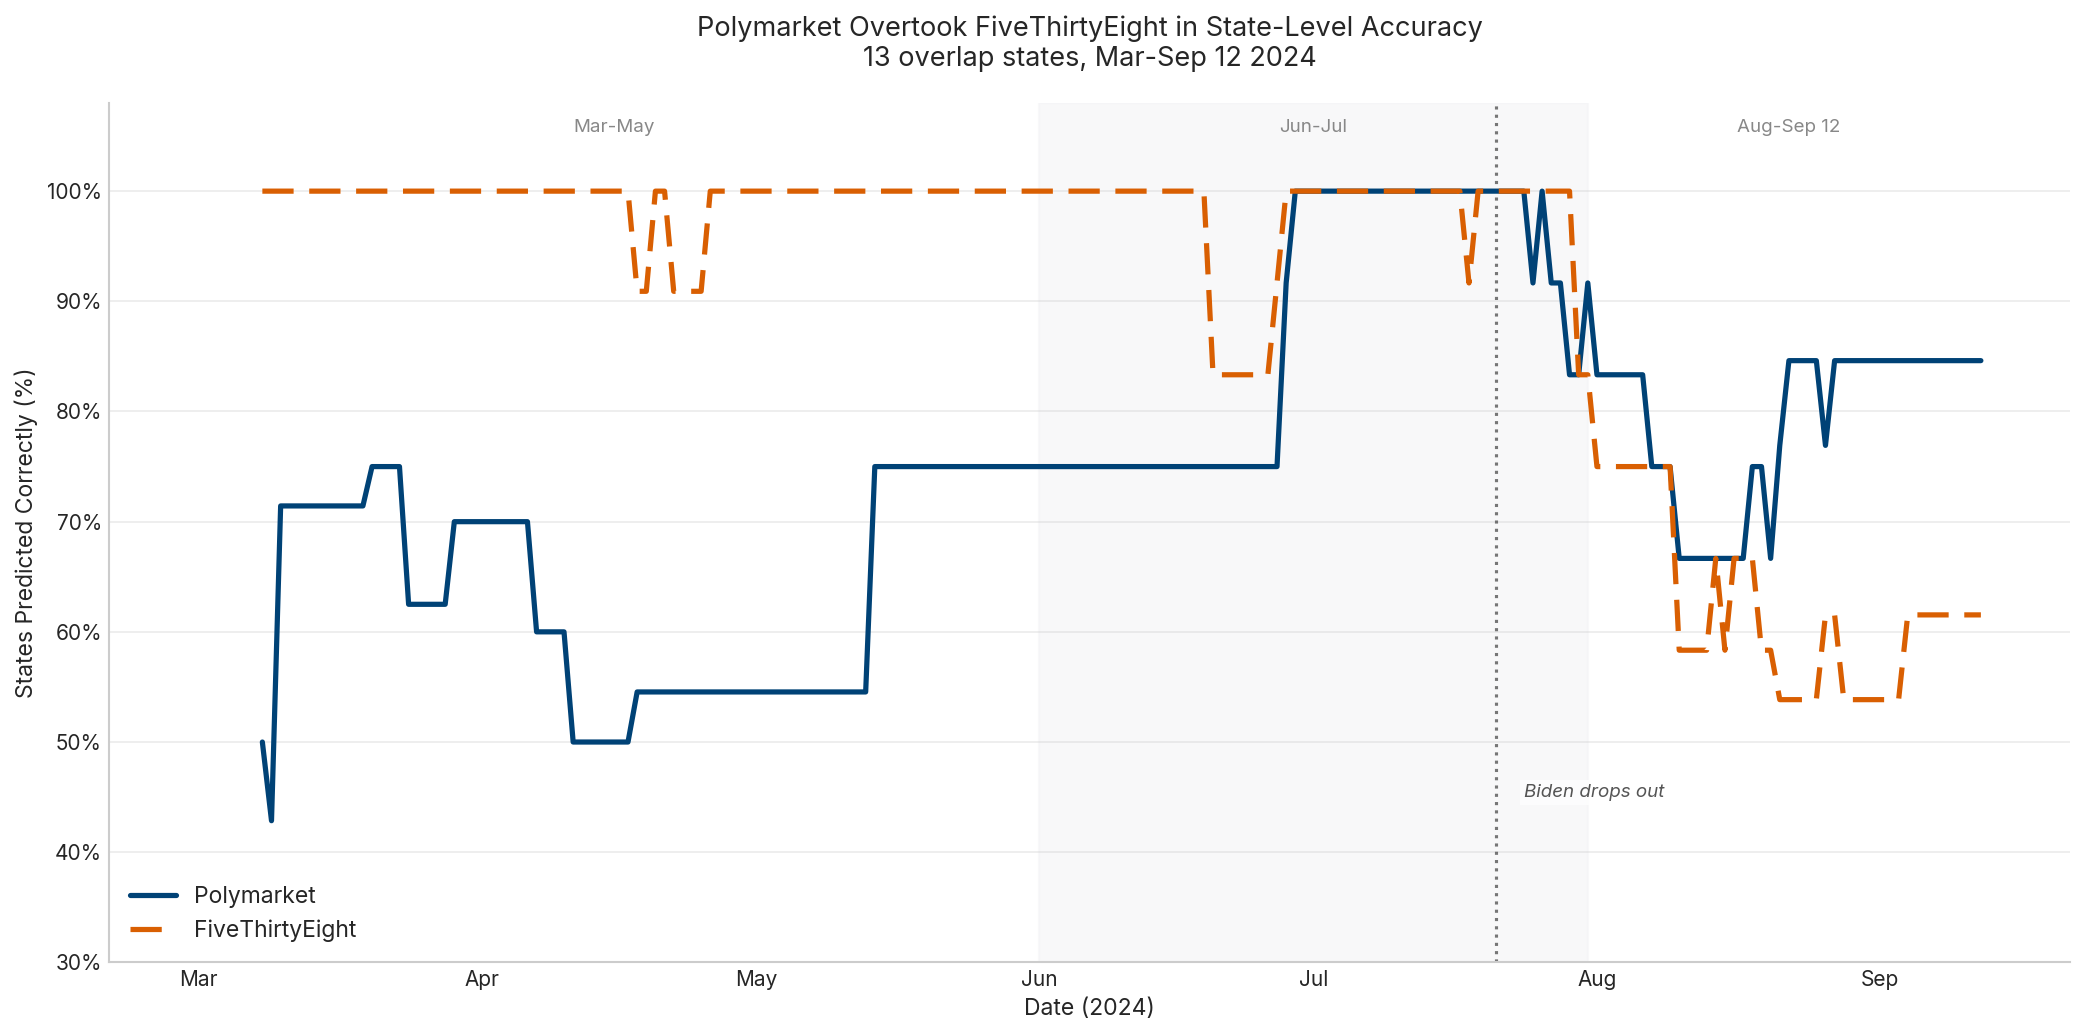

In [ ]:
# ---------------------------------------------------------------------------
# Time-series crossover figure
# ---------------------------------------------------------------------------

plot_timeseries_crossover(ts, show=True)


### Time-series interpretation

The crossover chart reveals a striking reversal. In the stable early months (Mar–May),
FiveThirtyEight's polling averages were nearly flawless — **99.4% daily accuracy** versus
Polymarket's **63.6%**. Polls correctly reflected an electorate that hadn't yet been
disrupted by major events.

Then Biden dropped out on July 21. In the Aug–Sep 12 period,
Polymarket pulled ahead at **79.2%** versus FiveThirtyEight's **62.2%**. Markets
recalibrated to the new Harris-vs-Trump race within days. Poll averages, weighed down by
outdated surveys, took longer to catch up.

Polls tend to be more accurate during stable periods, while prediction markets better capture the impact of major political shifts.

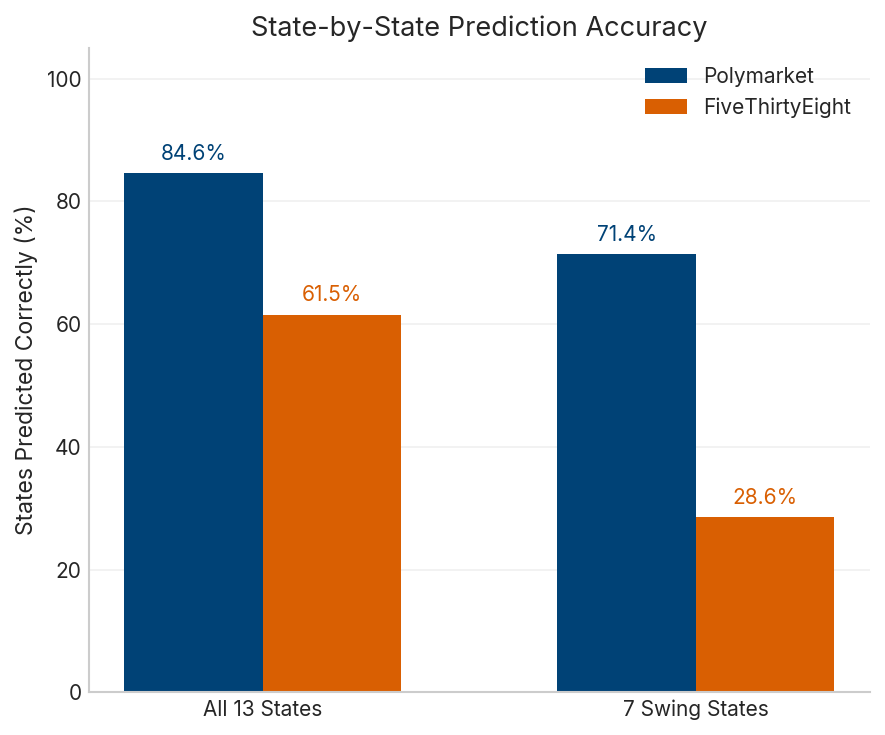

In [ ]:
# ---------------------------------------------------------------------------
# Head-to-head: Comparing accuracy state-by-state
# ---------------------------------------------------------------------------

plot_head_to_head(head_to_head, show=True)


In [ ]:
# --- Statistical significance: Fisher's exact test on winner-call counts ---
# With only 13 states (7 swing), the raw percentage gap could be noise.
# Fisher's exact test is the standard for small-sample 2×2 contingency tables.

# rows = [Polymarket, 538], cols = [correct, incorrect]
table_all = [[11, 2], [8, 5]]
_, p_all = fisher_exact(table_all)

table_swing = [[5, 2], [2, 5]]
_, p_swing = fisher_exact(table_swing)

print("Fisher's exact test (two-sided):")
print(f"  All 13 states:  PM 11/13 vs. 538 8/13  →  p = {p_all:.2f}")
print(f"  7 swing states: PM 5/7  vs. 538 2/7   →  p = {p_swing:.2f}")
print()
print("Neither difference is statistically significant at α = 0.05.")
print("The observed gap is suggestive but cannot rule out chance with n this small.")


### Head-to-head interpretation

September 12 is the cutoff because it's the date the last Polymarket state market
launched.

On that date, Polymarket correctly called **11 of 13 states (84.6%)** versus
FiveThirtyEight's **8 of 13 (61.5%)**. The gap widens in the swing states:
Polymarket got **5 of 7 (71.4%)** correct, while FiveThirtyEight managed only
**2 of 7 (28.6%)**. FiveThirtyEight's polling averages missed NC, NV, PA, MI, and WI —
all states that Trump ultimately won. Polymarket's only misses were MI and WI, where
Trump's margins were razor-thin.

**Statistical caveat:** with only 13 states (7 swing), these differences are not
statistically significant at conventional thresholds (Fisher's exact test: p = 0.38 for
all states, p = 0.29 for swing states). The observed gap is suggestive; Polymarket
outperformed on every subgroup and snapshot we tested, but we cannot rule out chance
from a single cross-section this small. The time-series analysis and EV-direction results below corroborate this finding beyond this single snapshot.

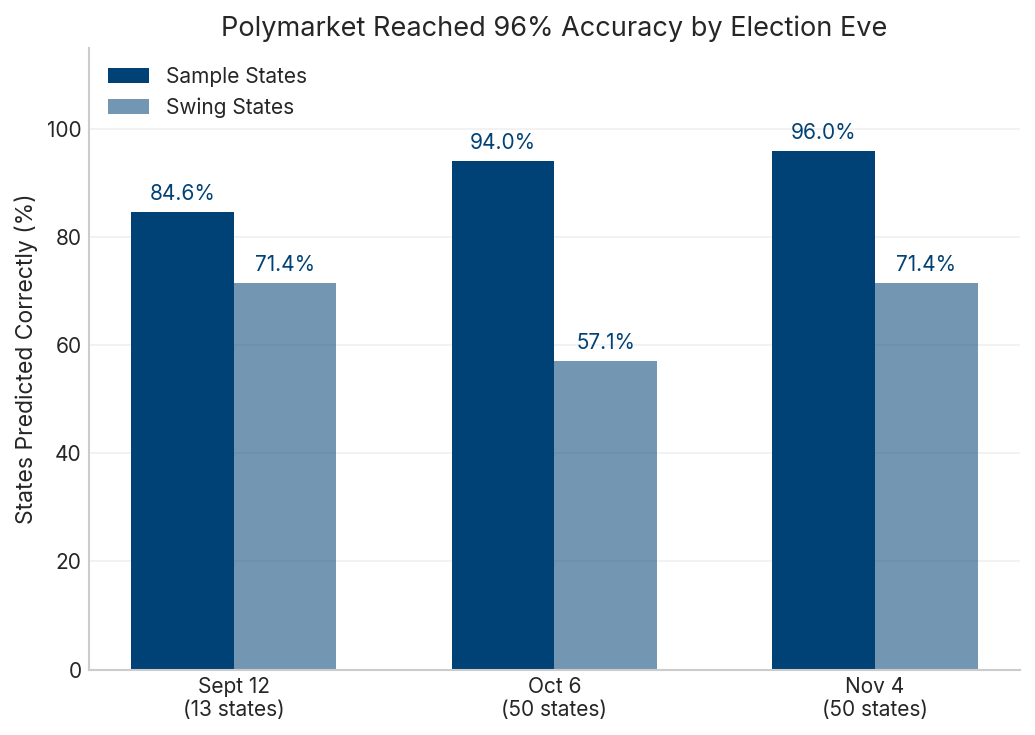

In [ ]:
# ---------------------------------------------------------------------------
# Polymarket accuracy at three points in time
# ---------------------------------------------------------------------------

plot_polymarket_trajectory(trajectory, show=True)


### Trajectory interpretation

As Polymarket expanded from 13 states to all 50, its accuracy climbed steadily:
**84.6%** on Sept 12 → **94.0%** on Oct 6 → **96.0%** on election eve. By November 4,
markets had correctly called 48 of 50 states.

The persistent misses were **Michigan and Wisconsin**, both states where Trump won by
less than 1 point. These were toss-up races that neither markets nor polls
reliably resolved before election day.

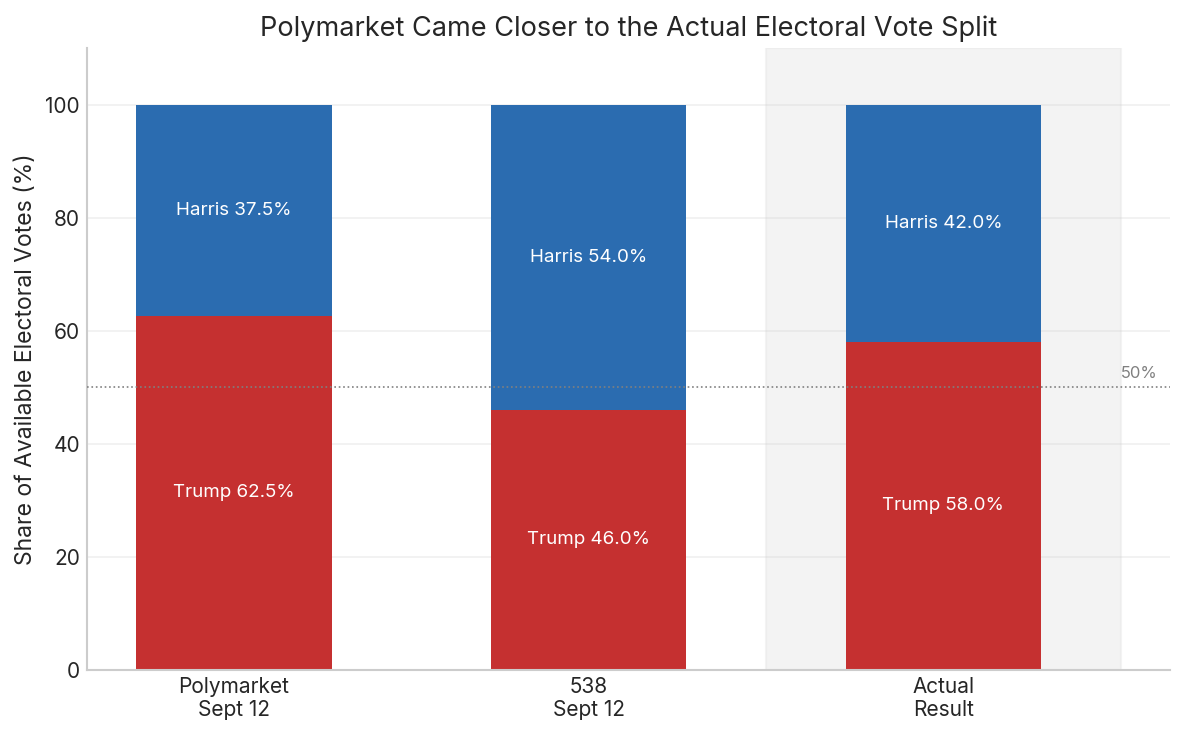

In [42]:
# ---------------------------------------------------------------------------
# Comparing projected electoral votes (Sep 12 vs. final)
# ---------------------------------------------------------------------------

plot_ev_comparison(ev, show=True)


### Electoral vote interpretation

This chart converts state-level winner predictions into projected Electoral College vote counts. On September 12, Polymarket's state-by-state predictions implied a **Trump-leaning split**, closer to the actual result where Trump won decisively. FiveThirtyEight's predictions showed a **Harris-leaning split**, getting the overall direction wrong.


## Conclusions

### Summary of findings

1. **Polymarket was more accurate overall, but the sample is small.** On the fairest
   comparison date (Sept 12), markets correctly called 84.6% of states versus 61.5% for
   polls. In swing states, the gap was even wider: 71.4% vs. 28.6%. However, with only
   13 states (7 swing), Fisher's exact tests show these differences are not statistically
   significant (p = 0.38 and p = 0.29). The pattern is consistent across every subgroup
   and time window we tested, but we cannot rule out chance from a single snapshot.

2. **The advantage wasn't always markets'.** In the stable early months (Mar–May),
   FiveThirtyEight dominated at 99.4% daily accuracy versus Polymarket's 63.6%. Markets
   only pulled ahead after the Biden dropout reshuffled the race.

3. **Markets correctly read the electoral map direction, while polls got it backwards.**
   Polymarket's Sept 12 predictions implied a Trump-leaning electoral vote split, which
   matched the actual outcome. FiveThirtyEight predicted a Harris-leaning split.

4. **Both sources shared blind spots.** Michigan and Wisconsin were missed by both
   Polymarket and FiveThirtyEight at every snapshot.

### Practical takeaway

Prediction markets and polls have complementary strengths. **Markets excel when the race
is shifting quickly**. They reprice overnight after candidate changes, debates, and
breaking news. **Polls excel in stable periods** where the underlying electorate hasn't
changed and the slow accumulation of survey data converges on the truth. Neither source
alone tells the full story, but understanding *when* each performs best is important for
anyone building election forecasts.

### Limitations

- **Small sample sizes** — The head-to-head comparison covers only 13 states (7 swing),
  and the accuracy differences are not statistically significant. All conclusions should
  be read as descriptive findings from a single election, not generalizable claims.
- **Overlap constraints** — The head-to-head comparison is limited to 13 states through
  Sept 12 because Polymarket's state markets launched at different times. This excludes
  the final two months of the campaign.
- **Binary winner calls** — We reduce rich probability/polling data to binary "Trump or
  Harris" calls. This misses the confidence each source assigned to its prediction.
- **Single election** — All findings are from one election cycle. Prediction markets may
  not maintain this advantage in elections without a major mid-campaign disruption.
- **Apples-to-oranges comparison** — Polymarket reports win probabilities while FiveThirtyEight reports vote shares. Both get converted to the same binary winner call, but the underlying quantities are fundamentally different.

### Further reading

This notebook establishes *what* each source got right and wrong. A companion analysis
([Event Response Analysis](./events.ipynb)) examines *how quickly and intensely* each
source reacted to specific campaign events — measuring reaction speed, z-scored intensity,
and directional accuracy for five major events including the Biden dropout,
the Trump assassination attempt, and the Harris-Trump debate.